### Plotting the result

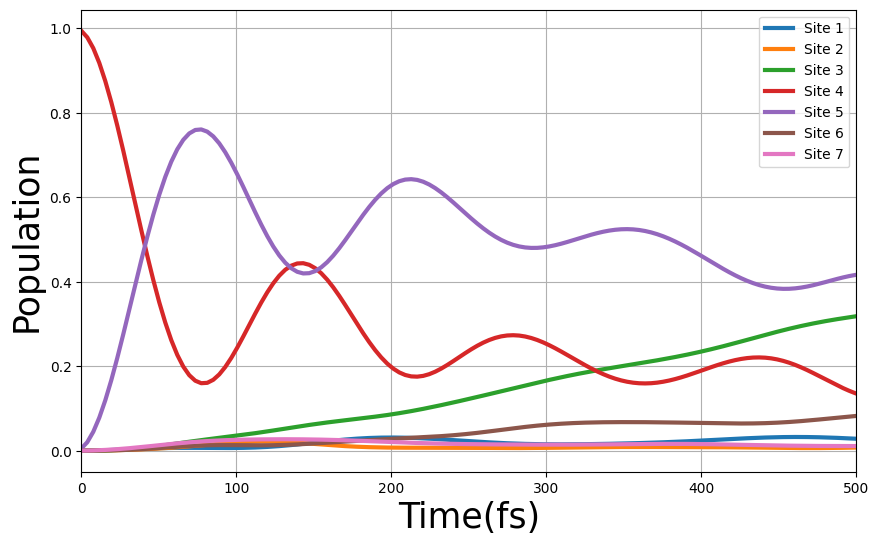

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取Excel文件
df = pd.read_excel('/curie-home/zengjj/Renormalizer/test/population/2026-01-27-0152_FMO16bd_160t.xlsx')
# df = pd.read_excel('/curie-home/zengjj/Renormalizer/test/fmo_benchmark.xlsx')

# 提取数据
x = np.arange(0,df.shape[0],1)
x = x * 160 * 0.024188843265

y_columns = df.iloc[:, 0:7]  # 第1-7列作为y坐标

# 创建图表
plt.figure(figsize=(10, 6))

# 绘制七条线
for i in range(0,7):
    plt.plot(x, y_columns.iloc[:, i],label=f'Site {i+1}',linewidth=3)

# 添加图表元素
plt.xlabel('Time(fs)',size = 25)
plt.ylabel('Population',size = 25)
plt.xlim((0, 500))
plt.title('')
plt.legend()
plt.grid(True)

# 显示图表
plt.show()

### Plotting the error

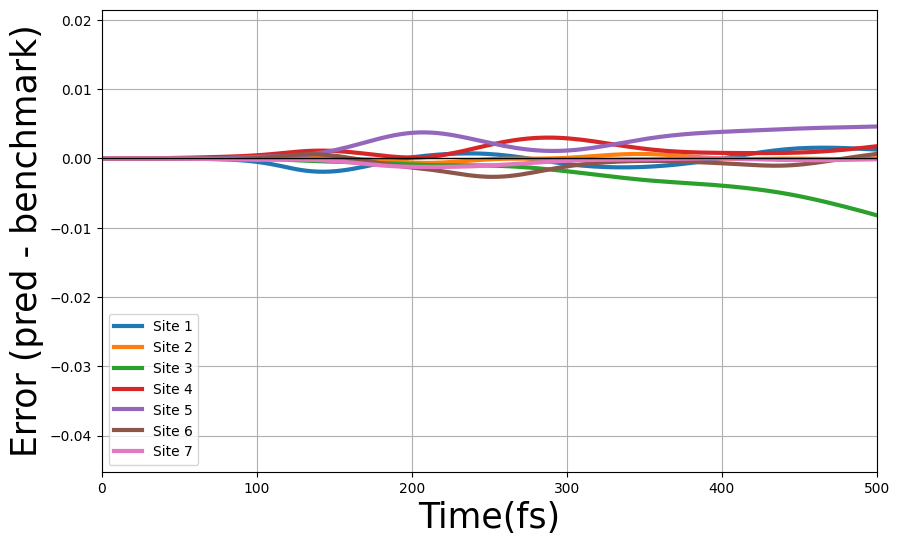

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 读取 benchmark（行数更多）
df_bm = pd.read_excel('/curie-home/zengjj/Renormalizer/test/population/fmo_benchmark_128bd.xlsx')

# 时间步长（与你第一张图一致）
dt = 160 * 0.024188843265

# pred(你的结果) 的时间轴：用第一张图里的 df（确保第一个 block 已运行）
x_pred = np.arange(df.shape[0]) * dt
y_pred = df.iloc[:, 0:7].to_numpy()

# benchmark 的时间轴
x_bm = np.arange(df_bm.shape[0]) * dt
y_bm = df_bm.iloc[:, 0:7].to_numpy()

# 将 benchmark 插值到 pred 的时间点上，然后算误差：pred - benchmark
y_bm_on_pred = np.column_stack([
    np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(7)
])
err = y_pred - y_bm_on_pred
# 如果你想画绝对误差：err = np.abs(err)

# 画误差图
plt.figure(figsize=(10, 6))
for i in range(7):
    plt.plot(x_pred, err[:, i], label=f'Site {i+1}', linewidth=3)

plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Time(fs)', size=25)
plt.ylabel('Error (pred - benchmark)', size=25)
plt.xlim((0, 500))
plt.title('')
plt.legend()
plt.grid(True)
plt.show()

Found 8 data files to plot.
Benchmark file: fmo_benchmark_128bd.xlsx
  - Plotted: FMO2bd_160t
  - Plotted: FMO4bd_160t
  - Plotted: FMO4bd_80t
  - Plotted: FMO8bd_160t
  - Plotted: FMO16bd_160t
  - Plotted: FMO32bd_160t
  - Plotted: FMO128bd_160t
  - Plotted: fmo_benchmark_32bd


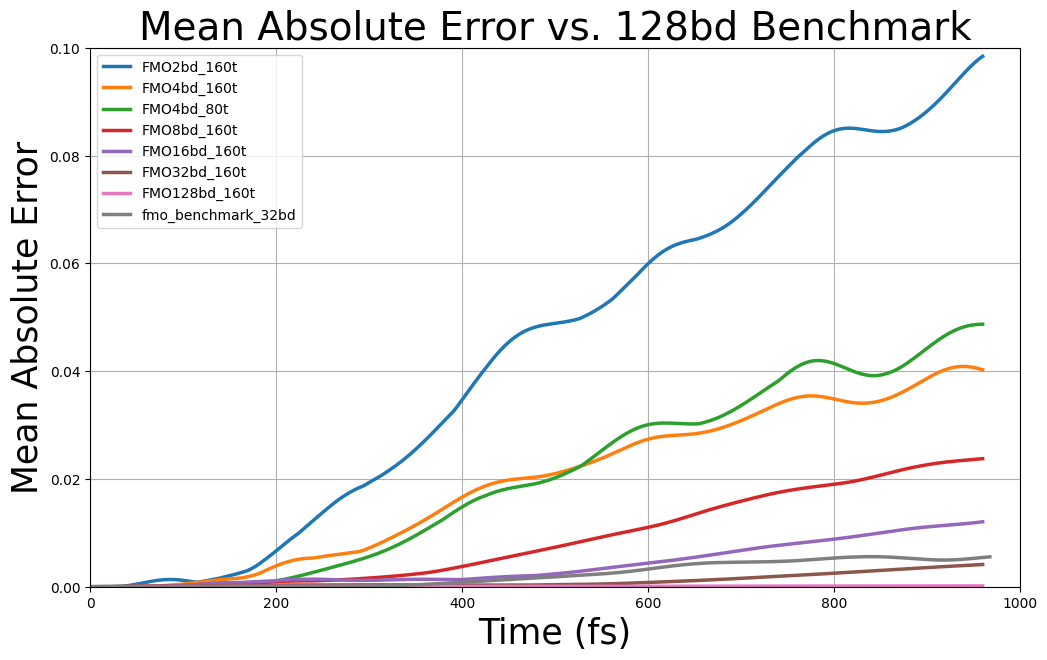

In [22]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_fmo_error():
    """
    Find all FMO simulation result files, compare them against
    the 128bd benchmark, and plot the mean absolute error over time.
    """

    # --- 1. Define paths ---
    test_dir = "/curie-home/zengjj/Renormalizer/test/population"

    benchmark_file = os.path.join(test_dir, 'fmo_benchmark_128bd.xlsx')
    extra_benchmark = os.path.join(test_dir, 'fmo_benchmark_32bd.xlsx')

    # Prediction files (normal FMO runs)
    fmo_files = sorted(
        glob.glob(os.path.join(test_dir, '2*FMO*bd_*t.xlsx'))
    )

    # Add 32bd benchmark as an additional curve if it exists
    data_files = fmo_files.copy()
    if os.path.exists(extra_benchmark):
        data_files.append(extra_benchmark)

    if not data_files:
        print("Warning: No data files found to plot.")
        return

    print(f"Found {len(data_files)} data files to plot.")
    print(f"Benchmark file: {os.path.basename(benchmark_file)}")

    # --- 2. Load benchmark (128bd) ---
    df_bm = pd.read_excel(benchmark_file)

    # --- 3. Prepare benchmark time axis ---
    dt = 160 * 0.024188843265
    x_bm = np.arange(df_bm.shape[0]) * dt
    y_bm = df_bm.iloc[:, 0:7].to_numpy()

    # --- 4. Create plot ---
    fig, ax = plt.subplots(figsize=(12, 7))

    # --- 5. Loop over all data files ---
    for f in data_files:
        df_pred = pd.read_excel(f)

        x_pred = np.arange(df_pred.shape[0]) * dt
        y_pred = df_pred.iloc[:, 0:7].to_numpy()

        # Interpolate benchmark onto prediction grid
        y_bm_on_pred = np.column_stack([
            np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(7)
        ])

        err = y_pred - y_bm_on_pred
        mean_abs_err = np.mean(np.abs(err), axis=1)

        # Label
        basename = os.path.basename(f)
        if basename.startswith("fmo_benchmark"):
            label = basename.replace(".xlsx", "")
        else:
            match = re.search(r'(FMO.*bd_.*t)', basename)
            label = match.group(1) if match else basename

        ax.plot(x_pred, mean_abs_err, label=label, linewidth=2.5)
        print(f"  - Plotted: {label}")

    # --- 6. Final formatting ---
    ax.set_xlabel('Time (fs)', size=25)
    ax.set_ylabel('Mean Absolute Error', size=25)
    ax.set_xlim((0, 1000))
    ax.set_ylim(bottom=0,top=0.1)
    ax.set_title('Mean Absolute Error vs. 128bd Benchmark', size=28)
    ax.legend()
    ax.grid(True)

    plt.show()


plot_fmo_error()